# Cards Classification

## About Dataset

 - 53 classes
 - 7624 train, 265 test, 265 validation images
 - 224 X 224 X 3 jpg format

The train, test and validation directories are partitioned into 53 subdirectories, one for each of the 53 types of cards. 
The dataset also includes a csv file which can be used to load the datasets.

In [1]:
import os

datasetDirectory = "dataset"
trainDirectory = datasetDirectory + "/train"
testDirectory = datasetDirectory + "/test"
validationDirectory = datasetDirectory + "/valid"

# Print all the directory name in the train directory
classesLabel = os.listdir(trainDirectory)
classesNumber = len(classesLabel)
print("Classes number: ", classesNumber)
print("Classes: ", classesLabel)

Classes number:  53
Classes:  ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs', 'eight of diamonds', 'eight of hearts', 'eight of spades', 'five of clubs', 'five of diamonds', 'five of hearts', 'five of spades', 'four of clubs', 'four of diamonds', 'four of hearts', 'four of spades', 'jack of clubs', 'jack of diamonds', 'jack of hearts', 'jack of spades', 'joker', 'king of clubs', 'king of diamonds', 'king of hearts', 'king of spades', 'nine of clubs', 'nine of diamonds', 'nine of hearts', 'nine of spades', 'queen of clubs', 'queen of diamonds', 'queen of hearts', 'queen of spades', 'seven of clubs', 'seven of diamonds', 'seven of hearts', 'seven of spades', 'six of clubs', 'six of diamonds', 'six of hearts', 'six of spades', 'ten of clubs', 'ten of diamonds', 'ten of hearts', 'ten of spades', 'three of clubs', 'three of diamonds', 'three of hearts', 'three of spades', 'two of clubs', 'two of diamonds', 'two of hearts', 'two of spades']


# Data Visualization

Image shape: (224, 224, 3)


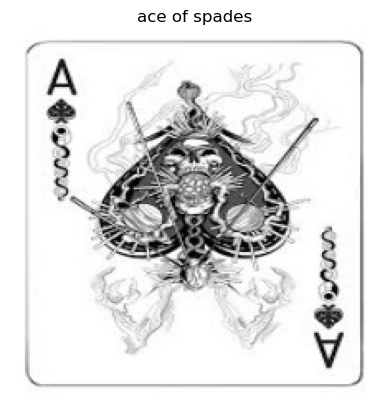

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def getRandomImage(target_dir, target_class):
    target_folder = target_dir + '/'+ target_class

    random_image = random.sample(os.listdir(target_folder), 1)# Get a random image path

    return mpimg.imread(target_folder + "/" + random_image[0])


target_class = random.choice(classesLabel)
img = getRandomImage(target_dir=trainDirectory,
                     target_class=target_class)

print(f"Image shape: {img.shape}") # show the shape of the image

plt.imshow(img)
plt.title(target_class)
plt.axis("off");

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data augmentation and normalization for training
transformTrain = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(10),
    transforms.ToTensor(),
    #transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

# Just normalization for validation
transformValidationTest = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

# Import the datasets from directory and apply the transforms
trainData = datasets.ImageFolder(trainDirectory, transform=transformTrain)
validData = datasets.ImageFolder(validationDirectory, transform=transformValidationTest)
testData = datasets.ImageFolder(testDirectory, transform=transformValidationTest)


# Define the dataloaders
batch_size = 32
train_dataloader = DataLoader(trainData, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(validData, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(testData, batch_size=batch_size, shuffle=False)

In [4]:
import torch.nn as nn
import torch.optim as optim

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=0)
        self.activationFunction1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
        self.activationFunction2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
        self.activationFunction3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 26 * 26, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, classesNumber)
        #self.sf = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.activationFunction1(self.conv1(x))
        out = self.pool1(out)
        out = self.activationFunction2(self.conv2(out))
        out = self.pool2(out)
        out = self.activationFunction3(self.conv3(out))
        out = self.pool3(out)

        out = self.flatten(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        #out = self.sf(out)
        return out


model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()#Implement already softmax
optimizer = optim.Adadelta(model.parameters(), lr=1)

from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           1,792
              ReLU-2         [-1, 64, 222, 222]               0
         MaxPool2d-3         [-1, 64, 111, 111]               0
            Conv2d-4         [-1, 64, 109, 109]          36,928
              ReLU-5         [-1, 64, 109, 109]               0
         MaxPool2d-6           [-1, 64, 54, 54]               0
            Conv2d-7           [-1, 64, 52, 52]          36,928
              ReLU-8           [-1, 64, 52, 52]               0
         MaxPool2d-9           [-1, 64, 26, 26]               0
          Flatten-10                [-1, 43264]               0
           Linear-11                  [-1, 128]       5,537,920
             ReLU-12                  [-1, 128]               0
           Linear-13                  [-1, 128]          16,512
             ReLU-14                  [

In [5]:
import numpy as np

epochs = 10

training_losses = []
training_accuracies = []
validation_losses = []
validation_accuracies = []

min_validation_loss = np.inf

for epoch in range(epochs):
    batch_loss = 0.0
    train_loss = 0.0
    total = 0
    correct = 0
    model.train()
    for i, (inputs, labels) in enumerate(train_dataloader, 1):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        batch_loss += loss.item()
        if i % 10 == 0:
            print(f'Epoch {epoch+1}, Batch {i}, Loss: {batch_loss/10:.5f}')
            batch_loss = 0.0

        # Get the accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    training_losses.append(train_loss/len(train_dataloader))
    training_accuracies.append(100 * correct / total)

    # Validation       
    validation_loss = 0.0
    total = 0
    correct = 0
    model.eval()
    for inputs, labels in valid_dataloader:
        # Get the loss
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        validation_loss += loss.item()
        # Get the accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    validation_losses.append(validation_loss/len(valid_dataloader))
    validation_accuracies.append(100 * correct / total)

    print(f'Epoch {epoch+1}\nTraining:\nLoss: {training_losses[-1]} Accuracy: {training_accuracies[-1]}\nValidation:\nLoss: {validation_losses[-1]} Accuracy: {validation_accuracies[-1]}')

    if min_validation_loss > validation_losses[-1]:
        print(f'Validation Loss Decreased({min_validation_loss:.6f}--->{validation_losses[-1]:.6f})\tSaving The Model')
        min_validation_loss = validation_losses[-1]

        torch.save(model.state_dict(), 'model.pth')

print('Finished Training')

Epoch 1, Batch 10, Loss: 4.02831
Epoch 1, Batch 20, Loss: 3.96996
Epoch 1, Batch 30, Loss: 3.96843
Epoch 1, Batch 40, Loss: 3.96241
Epoch 1, Batch 50, Loss: 3.98138
Epoch 1, Batch 60, Loss: 3.97281
Epoch 1, Batch 70, Loss: 3.96235
Epoch 1, Batch 80, Loss: 3.97403
Epoch 1, Batch 90, Loss: 3.97237
Epoch 1, Batch 100, Loss: 3.95510
Epoch 1, Batch 110, Loss: 3.99911
Epoch 1, Batch 120, Loss: 3.96664
Epoch 1, Batch 130, Loss: 3.95791
Epoch 1, Batch 140, Loss: 3.92697
Epoch 1, Batch 150, Loss: 3.93861
Epoch 1, Batch 160, Loss: 3.89220
Epoch 1, Batch 170, Loss: 3.63345
Epoch 1, Batch 180, Loss: 3.54239
Epoch 1, Batch 190, Loss: 3.40278
Epoch 1, Batch 200, Loss: 3.26670
Epoch 1, Batch 210, Loss: 3.27601
Epoch 1, Batch 220, Loss: 3.42890
Epoch 1, Batch 230, Loss: 3.15860
Epoch 1
Training:
Loss: 3.7617159997070186 Accuracy: 5.430220356768101
Validation:
Loss: 2.7707922988467746 Accuracy: 15.09433962264151
Validation Loss Decreased(inf--->2.770792)	Saving The Model
Epoch 2, Batch 10, Loss: 2.9461

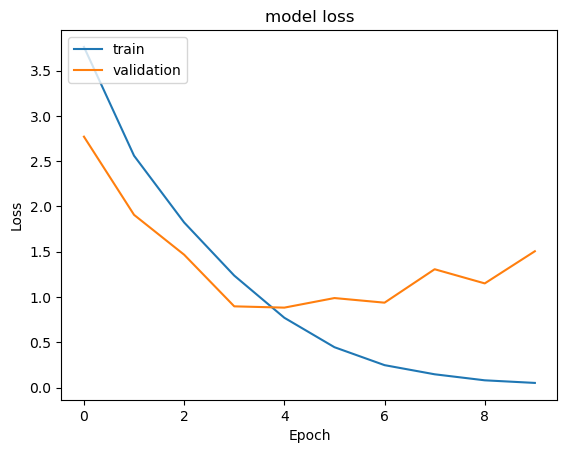

In [6]:
# Plot loss
plt.plot(training_losses)
plt.plot(validation_losses)
plt.title('model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [7]:
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test images: {100 * correct / total:.5f}%')

Accuracy on test images: 81.50943%


In [18]:
model.load_state_dict(torch.load('model.pth'))
model.eval()

y_pred = []
y_true = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_pred.extend(predicted.tolist())
        y_true.extend(labels.tolist())

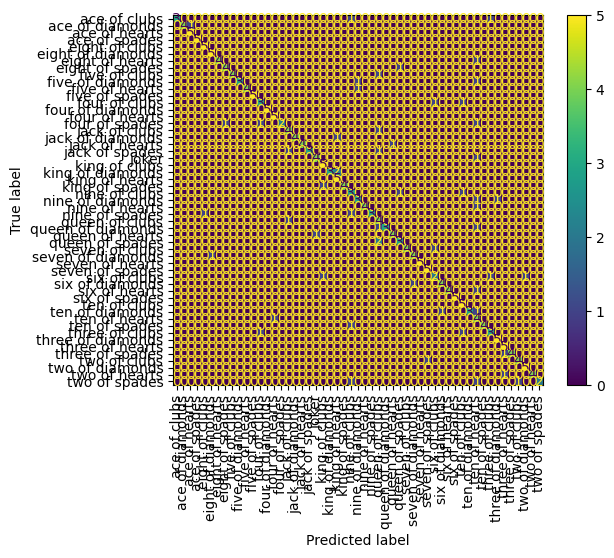

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=classesLabel).plot(xticks_rotation='vertical', include_values=True, cmap='viridis', ax=None, values_format=None, colorbar=True)

In [20]:
import sklearn.metrics as metrics
import numpy as np

print('Classification Report')
print(metrics.classification_report(y_true, y_pred, target_names=classesLabel))

Classification Report
                   precision    recall  f1-score   support

     ace of clubs       1.00      0.60      0.75         5
  ace of diamonds       1.00      0.80      0.89         5
    ace of hearts       0.83      1.00      0.91         5
    ace of spades       1.00      1.00      1.00         5
   eight of clubs       0.83      1.00      0.91         5
eight of diamonds       0.83      1.00      0.91         5
  eight of hearts       1.00      0.80      0.89         5
  eight of spades       0.80      0.80      0.80         5
    five of clubs       1.00      0.80      0.89         5
 five of diamonds       1.00      0.60      0.75         5
   five of hearts       1.00      0.80      0.89         5
   five of spades       1.00      1.00      1.00         5
    four of clubs       0.60      0.60      0.60         5
 four of diamonds       1.00      1.00      1.00         5
   four of hearts       0.83      1.00      0.91         5
   four of spades       1.00     